# Logistic Regression vs Artificial Neural Network

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow logging (1)

import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
from concurrent.futures import ThreadPoolExecutor

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [75]:
physical_gpus = tf.config.list_physical_devices('GPU')
print(f'Physical GPUs available: {physical_gpus}')

if physical_gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            physical_gpus[0],
            [
                tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2048),
                tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2048),
            ],
        )
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f'Logical GPUs after sharding: {logical_gpus}')
    except RuntimeError as error:
        print(f'GPU sharding could not be configured: {error}')
else:
    print('No GPU detected in this runtime.')

Physical GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU sharding could not be configured: Virtual devices cannot be modified after being initialized


## Data

In [ ]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=SEED)
display(X)
display(y)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
plt.title('Synthetic Dataset: Two Interleaving Half Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()   
plt.show()

### Splitting the Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [ ]:
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

## Applying Standard Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Definitions

In [76]:
from typing import Dict, Tuple
from concurrent.futures import ThreadPoolExecutor

class Model:
    def __init__(self, model_type: str = 'LR',
                 input_shape: Tuple[int, ...] = (2,),
                 hidden_activation: str = 'relu',
                 learning_rate: float = 0.001,
                 reg_type: str = 'l2',
                 regularization: float = 0.01,
                 n_hidden: int = 1,
                 n_hidden_neurons: Dict[int, int] = None,
                 epochs: int = 100,
                 batch_size: int = 128,
                 validation_split: float = 0.2):
        """
        Initializes the Model class.
        """
        if n_hidden_neurons is None:
            n_hidden_neurons = {i + 1: 8 for i in range(n_hidden)}
        self.model_type = model_type
        self.input_shape = input_shape
        self.hidden_activation = hidden_activation
        self.learning_rate = learning_rate
        self.reg_type = reg_type
        self.regularization = regularization
        self.n_hidden = n_hidden
        self.n_hidden_neurons = n_hidden_neurons
        self.epochs = epochs
        self.batch_size = batch_size
        self.validation_split = validation_split
        self.model = self.build_model()
        self.history = None

    def summary(self):
        if self.model:
            self.model.summary()
        else:
            print("Model has not been built yet.")

    def regularizer(self):
        if self.reg_type == 'l1':
            return regularizers.l1(self.regularization)
        elif self.reg_type == 'l2':
            return regularizers.l2(self.regularization)
        else:
            raise ValueError("Invalid regularization type. Choose 'l1' or 'l2'.")

    def build_model(self):
        if self.model_type == 'LR':
            model = models.Sequential([
                layers.Input(shape=self.input_shape),
                layers.Dense(1, activation='sigmoid', kernel_regularizer=self.regularizer()),
            ])
        elif self.model_type == 'ANN':
            model = models.Sequential()
            model.add(layers.Input(shape=self.input_shape))
            for i in range(1, self.n_hidden + 1):
                units = self.n_hidden_neurons.get(i, 8)
                model.add(
                    layers.Dense(
                        units,
                        activation=self.hidden_activation,
                        kernel_regularizer=self.regularizer(),
                    )
                )
            model.add(layers.Dense(1, activation='sigmoid'))
        else:
            raise ValueError("Invalid model type. Choose 'LR' or 'ANN'.")

        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def train_model(self, X_train, y_train, X_val, y_val, device_name: str = None):
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
        assert self.model is not None
        fit_kwargs = dict(
            x=X_train,
            y=y_train,
            validation_data=(X_val, y_val),
            epochs=self.epochs,
            batch_size=self.batch_size,
            callbacks=[early_stopping],
            verbose=2,
        )
        if device_name:
            with tf.device(device_name):
                self.history = self.model.fit(**fit_kwargs)
        else:
            self.history = self.model.fit(**fit_kwargs)
        return self.history

    def plot_history(self):
        if self.history is None:
            print("No training history found. Please train the model first.")
            return

        history = self.history
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Loss Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Accuracy Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, X_test, y_test):
        y_pred = (self.model.predict(X_test) > 0.5).astype('int32')
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

    def evaluate_model(self, X_test, y_test):
        y_pred = (self.model.predict(X_test) > 0.5).astype('int32')
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, zero_division=0)
        print(f"Accuracy: {accuracy:.4f}")
        print("Classification Report:")
        print(report)

    def plot_decision_boundary(self, X, y):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        Z = (self.model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5).astype('int32')
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))
        plt.contourf(xx, yy, Z, alpha=0.8)
        plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
        plt.title('Decision Boundary')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.show()

## Model Training Using Specs

Training devices: ['/GPU:0']
Epoch 1/200
25/25 - 2s - 66ms/step - accuracy: 0.7800 - loss: 0.4825 - val_accuracy: 0.8150 - val_loss: 0.4582
Epoch 2/200
25/25 - 0s - 6ms/step - accuracy: 0.7837 - loss: 0.4730 - val_accuracy: 0.8200 - val_loss: 0.4497
Epoch 3/200
25/25 - 0s - 6ms/step - accuracy: 0.7925 - loss: 0.4640 - val_accuracy: 0.8200 - val_loss: 0.4417
Epoch 4/200
25/25 - 0s - 6ms/step - accuracy: 0.7987 - loss: 0.4555 - val_accuracy: 0.8200 - val_loss: 0.4340
Epoch 5/200
25/25 - 0s - 6ms/step - accuracy: 0.7987 - loss: 0.4474 - val_accuracy: 0.8250 - val_loss: 0.4267
Epoch 6/200
25/25 - 0s - 6ms/step - accuracy: 0.8025 - loss: 0.4396 - val_accuracy: 0.8250 - val_loss: 0.4198
Epoch 7/200
25/25 - 0s - 6ms/step - accuracy: 0.8025 - loss: 0.4323 - val_accuracy: 0.8250 - val_loss: 0.4132
Epoch 8/200
25/25 - 0s - 6ms/step - accuracy: 0.8075 - loss: 0.4252 - val_accuracy: 0.8250 - val_loss: 0.4069
Epoch 9/200
25/25 - 0s - 6ms/step - accuracy: 0.8100 - loss: 0.4185 - val_accuracy: 0.8250

,label,model_type,hidden_activation,regularization,loss,accuracy
0,Shallow_relu_l1,ANN,relu,l1,0.136816,0.990
1,Deep_relu_l1,ANN,relu,l1,1.128469,0.500
2,Shallow_relu_l2,ANN,relu,l2,0.103434,0.985
3,Deep_relu_l2,ANN,relu,l2,0.693157,0.500
4,Shallow_tanh_l1,ANN,tanh,l1,0.265848,0.870
5,Deep_tanh_l1,ANN,tanh,l1,1.126266,0.500
6,Shallow_tanh_l2,ANN,tanh,l2,0.252196,0.870
7,Deep_tanh_l2,ANN,tanh,l2,0.211166,1.000
8,LR_relu_l1,LR,relu,l1,0.286681,0.870
9,LR_relu_l2,LR,relu,l2,0.327895,0.850


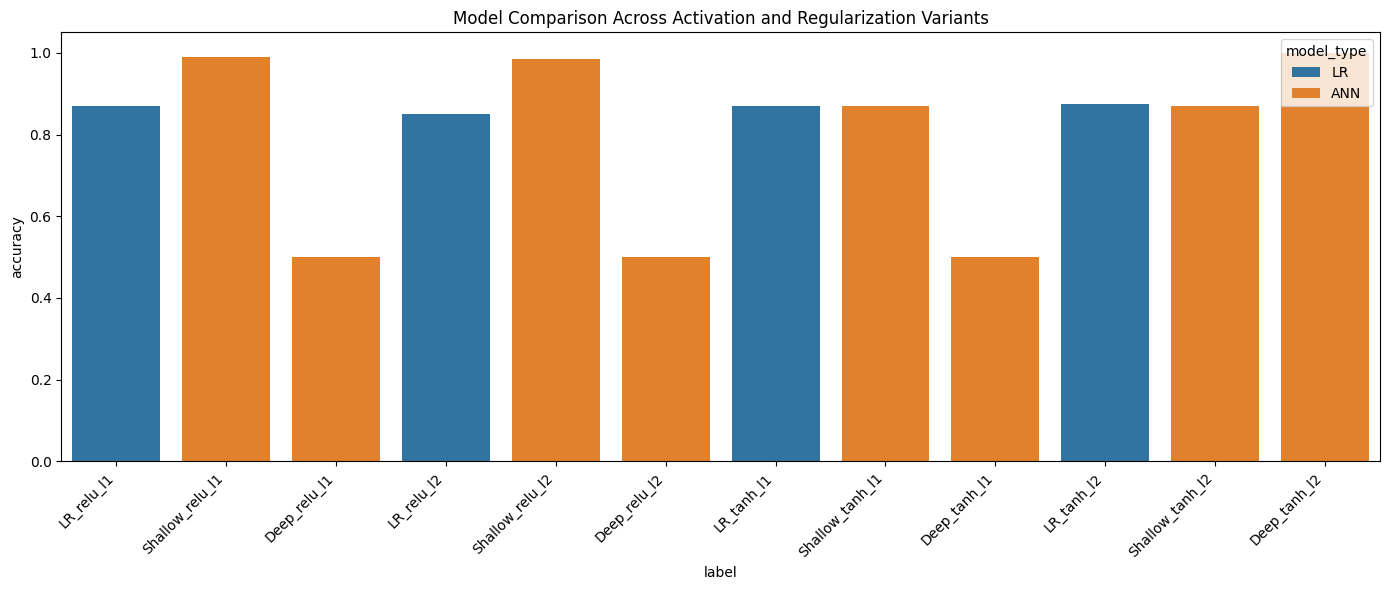

In [78]:
def build_experiment_specs():
    deep_neurons = {1: 8, 2: 16, 3: 32, 4: 64, 5: 128, 6: 256, 7: 512, 8: 256, 9: 128, 10: 64, 11: 32, 12: 16, 13: 8}
    grid = [
        ('relu', 'l1'),
        ('relu', 'l2'),
        ('tanh', 'l1'),
        ('tanh', 'l2'),
    ]
    specs = []
    for activation, reg_type in grid:
        specs.append({
            'label': f'LR_{activation}_{reg_type}',
            'kwargs': {
                'model_type': 'LR',
                'input_shape': (2,),
                'hidden_activation': activation,
                'learning_rate': 0.001,
                'reg_type': reg_type,
                'regularization': 0.01,
                'epochs': 200,
                'batch_size': 32,
            },
        })
        specs.append({
            'label': f'Shallow_{activation}_{reg_type}',
            'kwargs': {
                'model_type': 'ANN',
                'input_shape': (2,),
                'hidden_activation': activation,
                'learning_rate': 0.001,
                'reg_type': reg_type,
                'regularization': 0.01,
                'n_hidden': 1,
                'n_hidden_neurons': {1: 32},
                'epochs': 200,
                'batch_size': 32,
            },
        })
        specs.append({
            'label': f'Deep_{activation}_{reg_type}',
            'kwargs': {
                'model_type': 'ANN',
                'input_shape': (2,),
                'hidden_activation': activation,
                'learning_rate': 0.001,
                'reg_type': reg_type,
                'regularization': 0.01,
                'n_hidden': 13,
                'n_hidden_neurons': deep_neurons,
                'epochs': 200,
                'batch_size': 64,
            },
        })
    return specs


def train_spec(spec, device_name):
    with tf.device(device_name):
        model = Model(**spec['kwargs'])
    model.train_model(X_train, y_train, X_test, y_test, device_name=device_name)
    loss, accuracy = model.model.evaluate(X_test, y_test, verbose=0)
    return {
        'label': spec['label'],
        'model_type': spec['kwargs']['model_type'],
        'hidden_activation': spec['kwargs'].get('hidden_activation', 'n/a'),
        'regularization': spec['kwargs']['reg_type'],
        'loss': float(loss),
        'accuracy': float(accuracy),
        'model': model,
    }

logical_gpu_devices = [device.name for device in tf.config.list_logical_devices('GPU')]
if len(logical_gpu_devices) >= 2:
    training_devices = logical_gpu_devices[:2]
elif physical_gpus:
    training_devices = ['/GPU:0']
else:
    training_devices = ['/CPU:0']
print(f'Training devices: {training_devices}')

experiment_specs = build_experiment_specs()
experiment_results = []

for start_index in range(0, len(experiment_specs), len(training_devices)):
    batch_specs = experiment_specs[start_index:start_index + len(training_devices)]
    with ThreadPoolExecutor(max_workers=len(batch_specs)) as executor:
        futures = [
            executor.submit(train_spec, spec, training_devices[index])
            for index, spec in enumerate(batch_specs)
        ]
        for future in futures:
            experiment_results.append(future.result())

results_df = pd.DataFrame([
    {key: value for key, value in result.items() if key != 'model'}
    for result in experiment_results
])

display(results_df.sort_values(['model_type', 'hidden_activation', 'regularization']).reset_index(drop=True))

plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x='label', y='accuracy', hue='model_type')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison Across Activation and Regularization Variants')
plt.tight_layout()
plt.show()